<a href="https://colab.research.google.com/github/Himanshu4730/Data-Science-Assignment2---Movie-Data-Analysis-Project-3000-Movies-Dataset-/blob/main/DATASCIENCEASSIGNMENT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **You have been hired by a rookie movie producer to help him decide what type of movies to produce and which actors to cast. You have to back your recommendations based on thorough analysis of the data he shared with you which has the list of 3000 movies and the corresponding details.**




# **As a data scientist, you have to first explore the data and check its sanity.**

# **Further, you have to answer the following questions:**
1. Which movie made the highest profit? Who were its producer and director? Identify the actors in that film.
2. This data has information about movies made in different languages. Which language has the highest average ROI (return on investment)?
3. Find out the unique genres of movies in this dataset.
4. Make a table of all the producers and directors of each movie. Find the top 3 producers who have produced movies with the highest average RoI?
5. Which actor has acted in the most number of movies? Deep dive into the movies, genres and profits corresponding to this actor.
6. Top 3 directors prefer which actors the most?

# **Data Preparation & Sanity Check**

# **Install & Import**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import ast
import warnings

warnings.filterwarnings("ignore")

# ── Plot style ──────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 6)

print("✅  All libraries imported successfully.")

✅  All libraries imported successfully.


# **LOAD & SANITY CHECK**


📦  Dataset shape  : 3000 rows × 23 columns

🔍  First 3 rows:


,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000



📋  Column data types:
id                         int64
belongs_to_collection     object
budget                     int64
genres                    object
homepage                  object
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity               float64
poster_path               object
production_companies      object
production_countries      object
release_date              object
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title                     object
Keywords                  object
cast                      object
crew                      object
revenue                    int64
dtype: object

⚠️  Columns with missing values:


,Missing Count,Missing %
belongs_to_collection,2396,79.87
homepage,2054,68.47
tagline,597,19.90
Keywords,276,9.20
production_companies,156,5.20
production_countries,55,1.83
spoken_languages,20,0.67
crew,16,0.53
cast,13,0.43
overview,8,0.27


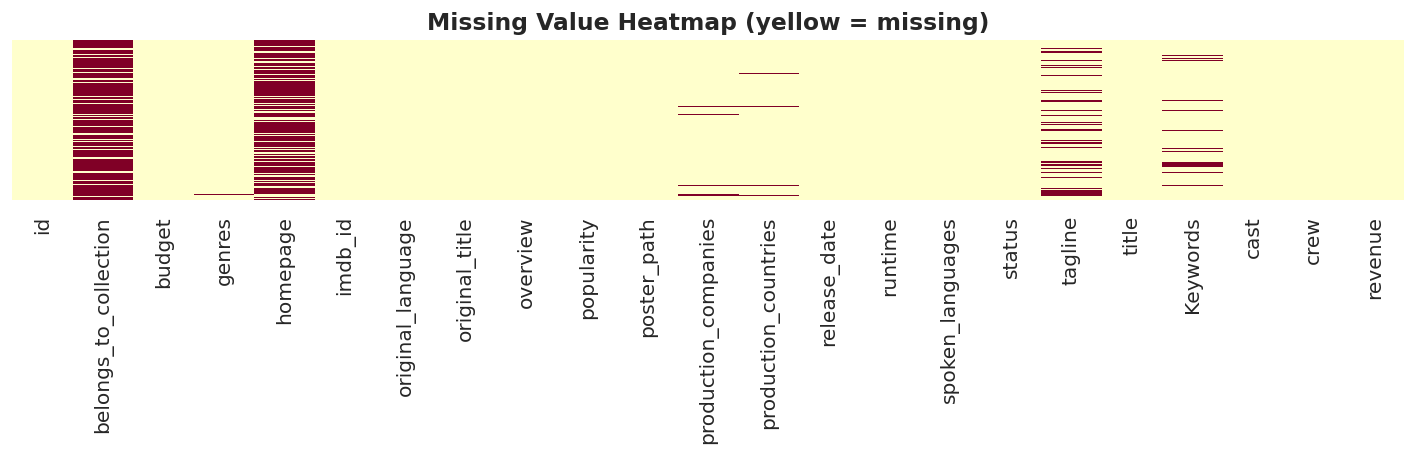

In [24]:
df = pd.read_csv('/content/movies_data.csv', engine='python', on_bad_lines='skip')   # ← change path if needed
print(f"\n📦  Dataset shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print("\n🔍  First 3 rows:")
display(df.head(3))

print("\n📋  Column data types:")
print(df.dtypes)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

print("\n⚠️  Columns with missing values:")
display(missing_df)

# Heatmap of missing values
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="YlOrRd")
plt.title("Missing Value Heatmap (yellow = missing)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# **Basic statistics for numeric columns**

In [25]:
print("\n📊  Descriptive statistics:")
display(df[["budget", "revenue", "popularity", "runtime"]].describe().applymap("{:,.2f}".format))

# ── 1.5  Drop rows where budget or revenue is 0 ─────────────
# (Can't compute profit / ROI meaningfully)
df_clean = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()
print(f"\n🧹  After removing zero-budget/revenue rows : {len(df_clean)} movies remain "
      f"(removed {len(df) - len(df_clean)})")


📊  Descriptive statistics:


,budget,revenue,popularity,runtime
count,"3,000.00","3,000.00","3,000.00","2,998.00"
mean,"22,531,334.11","66,725,851.89",8.46,107.86
std,"37,026,086.41","137,532,326.34",12.10,22.09
min,0.00,1.00,0.00,0.00
25%,0.00,"2,379,808.25",4.02,94.00
50%,"8,000,000.00","16,807,068.00",7.37,104.00
75%,"29,000,000.00","68,919,203.50",10.89,118.00
max,"380,000,000.00","1,519,557,910.00",294.34,338.00



🧹  After removing zero-budget/revenue rows : 2188 movies remain (removed 812)


# **HELPER PARSERS**

In [26]:
def safe_parse(val):
    """Safely parse a stringified Python list/dict."""
    try:
        return ast.literal_eval(val) if isinstance(val, str) else []
    except Exception:
        return []

def extract_names(val, key="name"):
    """Return a list of values for a given key from a JSON-like string."""
    records = safe_parse(val)
    return [r.get(key, "") for r in records if isinstance(r, dict)]

def extract_crew_by_job(val, job_title):
    """Return names of crew members with a specific job title."""
    records = safe_parse(val)
    return [r["name"] for r in records
            if isinstance(r, dict) and r.get("job", "").lower() == job_title.lower()]

# ── Parse key columns ────────────────────────────────────────
df_clean["genre_list"]    = df_clean["genres"].apply(extract_names)
df_clean["cast_list"]     = df_clean["cast"].apply(extract_names)
df_clean["director_list"] = df_clean["crew"].apply(lambda x: extract_crew_by_job(x, "Director"))
df_clean["producer_list"] = df_clean["crew"].apply(lambda x: extract_crew_by_job(x, "Producer"))

# ── Derived metrics ──────────────────────────────────────────
df_clean["profit"] = df_clean["revenue"] - df_clean["budget"]
df_clean["roi"]    = ((df_clean["revenue"] - df_clean["budget"]) / df_clean["budget"]) * 100

print(f"\n✅  Profit & ROI columns added. Sample:")
display(df_clean[["title", "budget", "revenue", "profit", "roi"]].head(5))


✅  Profit & ROI columns added. Sample:


,title,budget,revenue,profit,roi
0,Hot Tub Time Machine 2,14000000,12314651,-1685349,-12.038207
1,The Princess Diaries 2: Royal Engagement,40000000,95149435,55149435,137.873588
2,Whiplash,3300000,13092000,9792000,296.727273
3,Kahaani,1200000,16000000,14800000,1233.333333
5,Pinocchio and the Emperor of the Night,8000000,3261638,-4738362,-59.229525


# **EDA OVERVIEW**

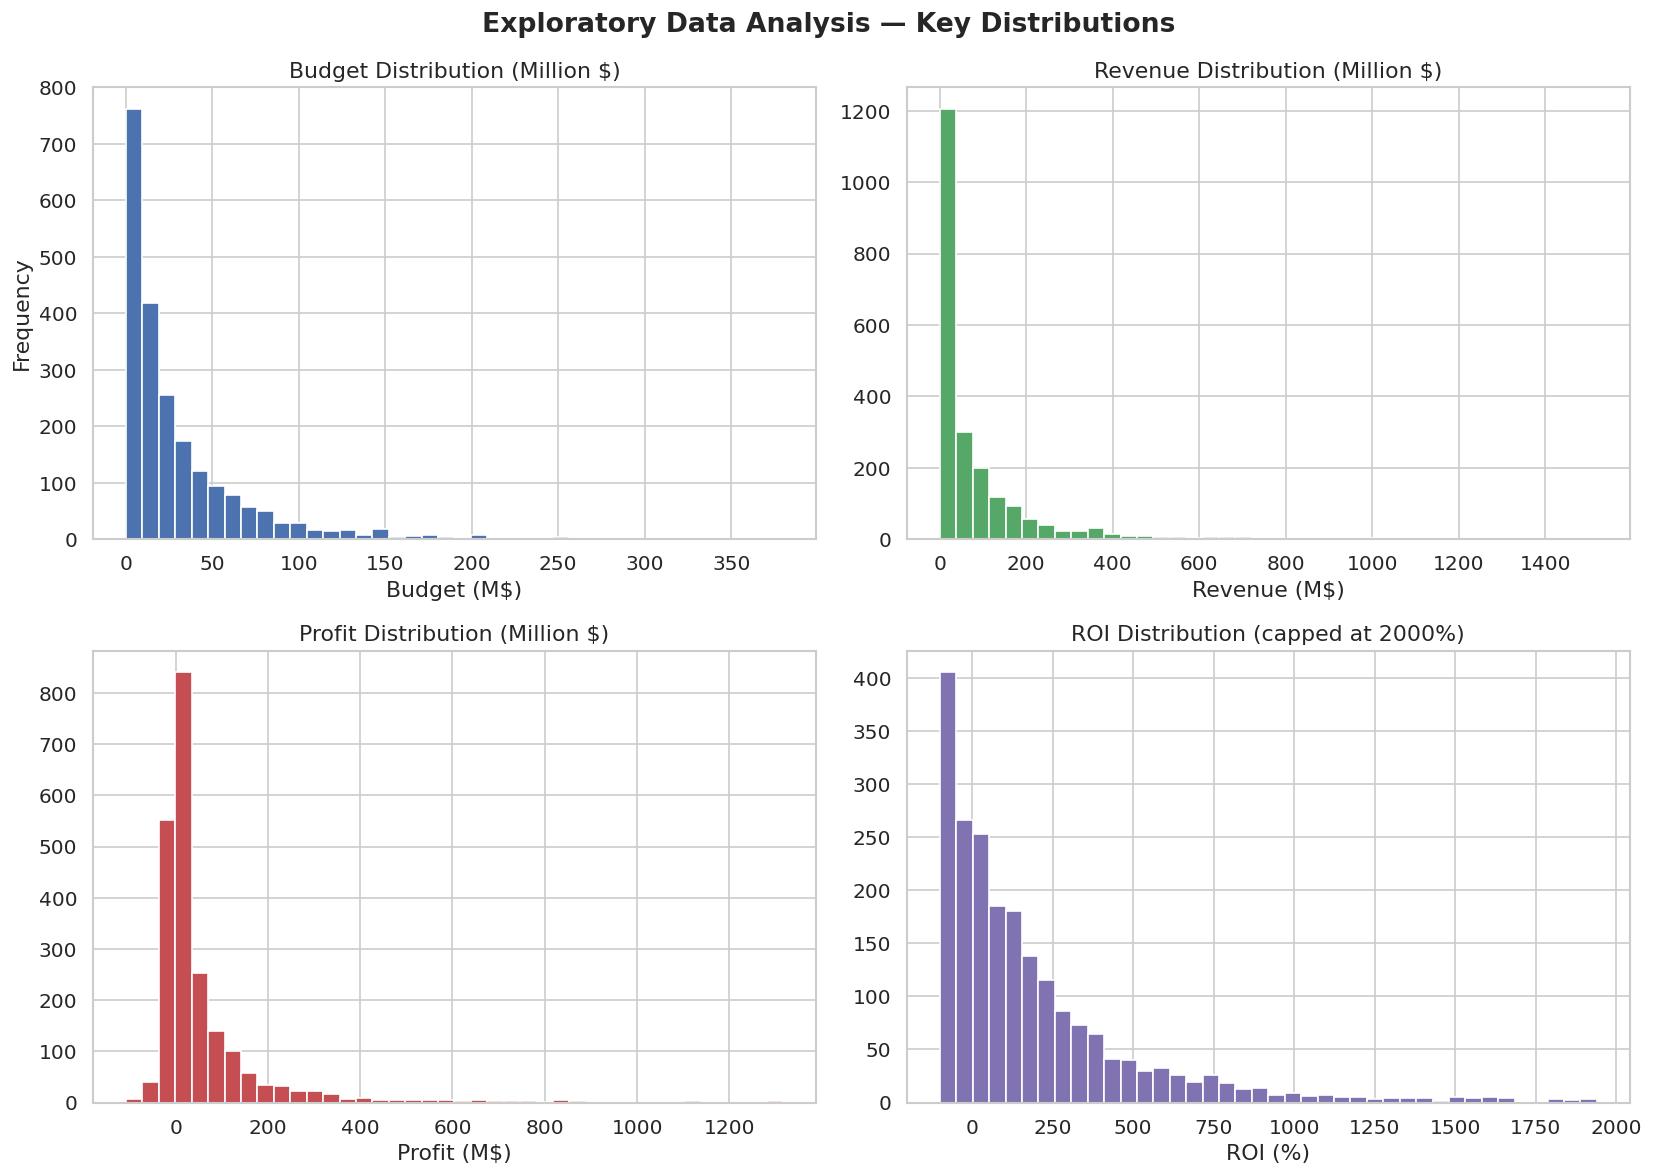

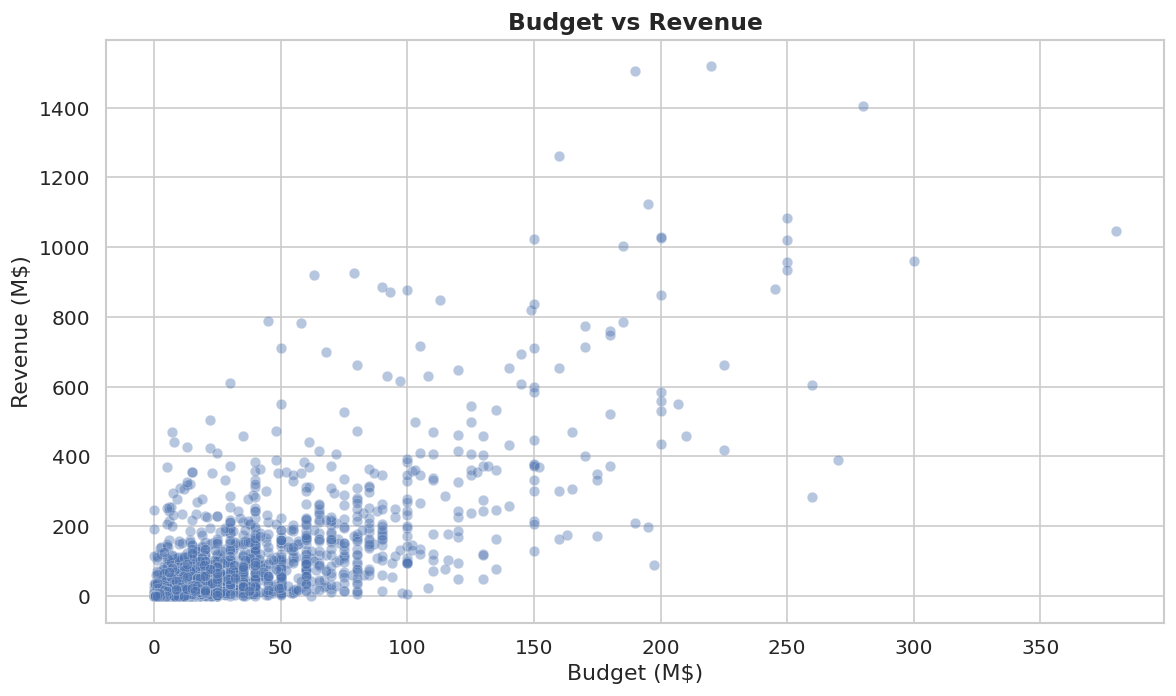

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Exploratory Data Analysis — Key Distributions", fontsize=16, fontweight="bold")

# Budget distribution
axes[0, 0].hist(df_clean["budget"] / 1e6, bins=40, color="#4C72B0", edgecolor="white")
axes[0, 0].set_title("Budget Distribution (Million $)")
axes[0, 0].set_xlabel("Budget (M$)")
axes[0, 0].set_ylabel("Frequency")

# Revenue distribution
axes[0, 1].hist(df_clean["revenue"] / 1e6, bins=40, color="#55A868", edgecolor="white")
axes[0, 1].set_title("Revenue Distribution (Million $)")
axes[0, 1].set_xlabel("Revenue (M$)")

# Profit distribution
axes[1, 0].hist(df_clean["profit"] / 1e6, bins=40, color="#C44E52", edgecolor="white")
axes[1, 0].set_title("Profit Distribution (Million $)")
axes[1, 0].set_xlabel("Profit (M$)")

# ROI distribution (capped at 2000% for visibility)
roi_capped = df_clean[df_clean["roi"] < 2000]["roi"]
axes[1, 1].hist(roi_capped, bins=40, color="#8172B2", edgecolor="white")
axes[1, 1].set_title("ROI Distribution (capped at 2000%)")
axes[1, 1].set_xlabel("ROI (%)")

plt.tight_layout()
plt.show()

# Budget vs Revenue scatter
plt.figure(figsize=(10, 6))
plt.scatter(df_clean["budget"] / 1e6, df_clean["revenue"] / 1e6,
            alpha=0.4, color="#4C72B0", edgecolors="white", linewidth=0.3, s=40)
plt.xlabel("Budget (M$)")
plt.ylabel("Revenue (M$)")
plt.title("Budget vs Revenue", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# **1- Which movie made the highest profit? Who were its producer and director? Identify the actors in that film.**


   Q1 : HIGHEST PROFIT MOVIE

🏆  Title           : Furious 7
💰  Budget          : $190,000,000
💵  Revenue         : $1,506,249,360
📈  Profit          : $1,316,249,360
📊  ROI             : 692.8%
🎬  Director(s)     : James Wan
🎥  Producer(s)     : Vin Diesel, Neal H. Moritz, Michael Fottrell, Brandon Birtell
🎭  Cast (Top 10)   : Vin Diesel, Paul Walker, Dwayne Johnson, Michelle Rodriguez, Tyrese Gibson, Ludacris, Jordana Brewster, Djimon Hounsou, Tony Jaa, Ronda Rousey


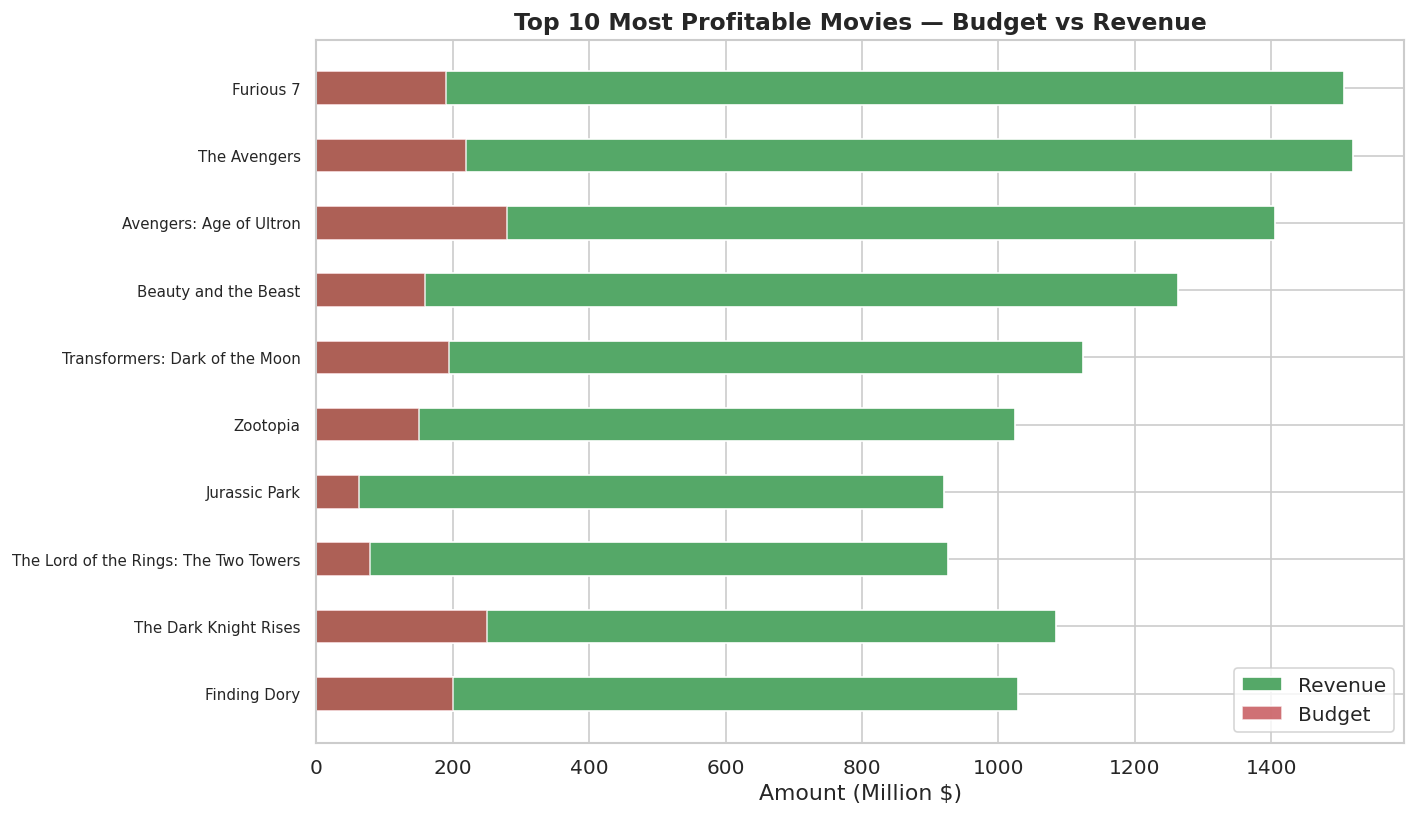

In [28]:
print("\n" + "="*60)
print("   Q1 : HIGHEST PROFIT MOVIE")
print("="*60)

top_profit = df_clean.loc[df_clean["profit"].idxmax()]

print(f"\n🏆  Title           : {top_profit['title']}")
print(f"💰  Budget          : ${top_profit['budget']:,.0f}")
print(f"💵  Revenue         : ${top_profit['revenue']:,.0f}")
print(f"📈  Profit          : ${top_profit['profit']:,.0f}")
print(f"📊  ROI             : {top_profit['roi']:.1f}%")
print(f"🎬  Director(s)     : {', '.join(top_profit['director_list']) or 'N/A'}")
print(f"🎥  Producer(s)     : {', '.join(top_profit['producer_list']) or 'N/A'}")
print(f"🎭  Cast (Top 10)   : {', '.join(top_profit['cast_list'][:10])}")

# Visualise budget vs revenue for top 10 profit movies
top10_profit = df_clean.nlargest(10, "profit")[["title", "budget", "revenue", "profit"]].copy()
top10_profit = top10_profit.sort_values("profit", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
y = range(len(top10_profit))
ax.barh(y, top10_profit["revenue"] / 1e6, color="#55A868", label="Revenue", height=0.5)
ax.barh(y, top10_profit["budget"] / 1e6, color="#C44E52", label="Budget", height=0.5, alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(top10_profit["title"], fontsize=9)
ax.set_xlabel("Amount (Million $)")
ax.set_title("Top 10 Most Profitable Movies — Budget vs Revenue", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# **2- This data has information about movies made in different languages. Which language has the highest average ROI (return on investment)?**


   Q2 : LANGUAGE WITH HIGHEST AVERAGE ROI

🌍  Top 10 Languages by Average ROI (min 5 movies):


,Language,Avg ROI (%),# Movies
0,ko,3.817941e+07,11
1,en,5.439874e+05,1943
2,de,4.349067e+02,11
3,zh,4.084563e+02,14
4,es,3.794217e+02,17
5,hi,2.713313e+02,39
6,ta,2.155159e+02,13
7,ja,1.858405e+02,18
8,cn,1.738661e+02,8
9,fr,1.705117e+02,39



🥇  Highest Avg ROI Language : 'KO'  →  38179410.2% (based on 11 movies)


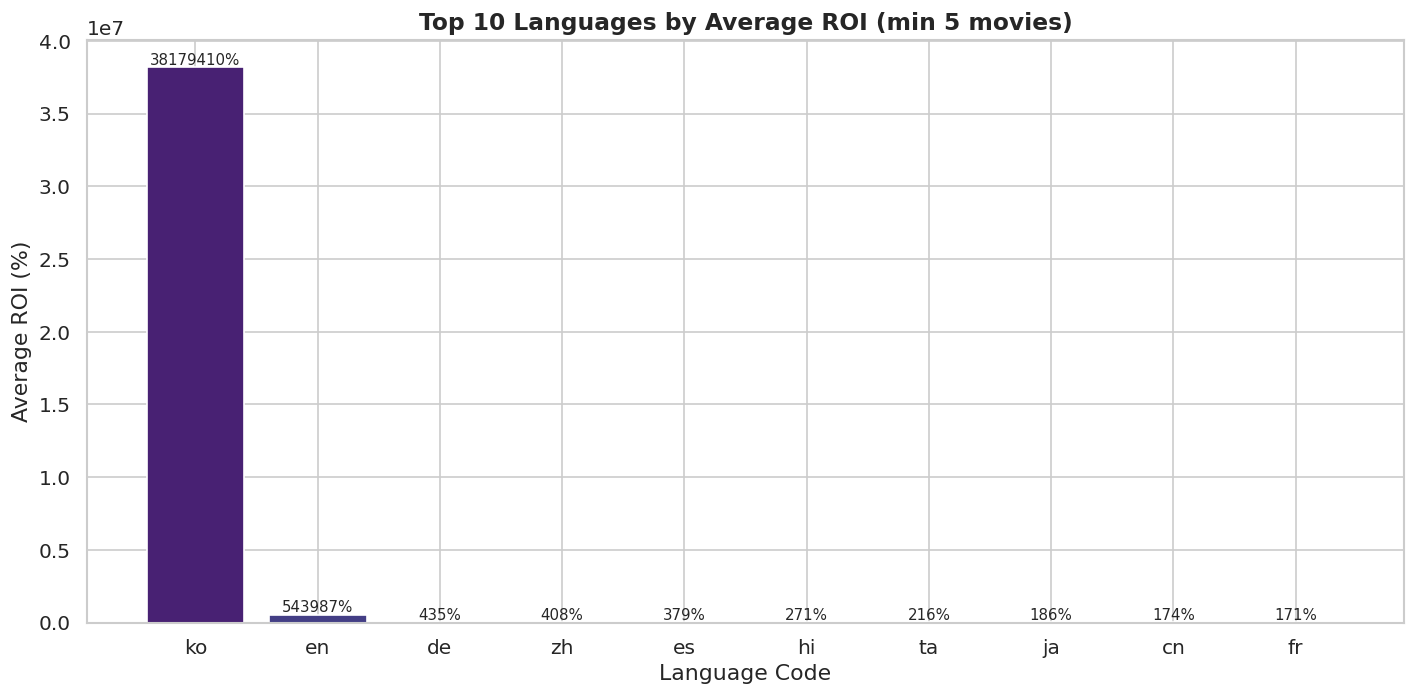

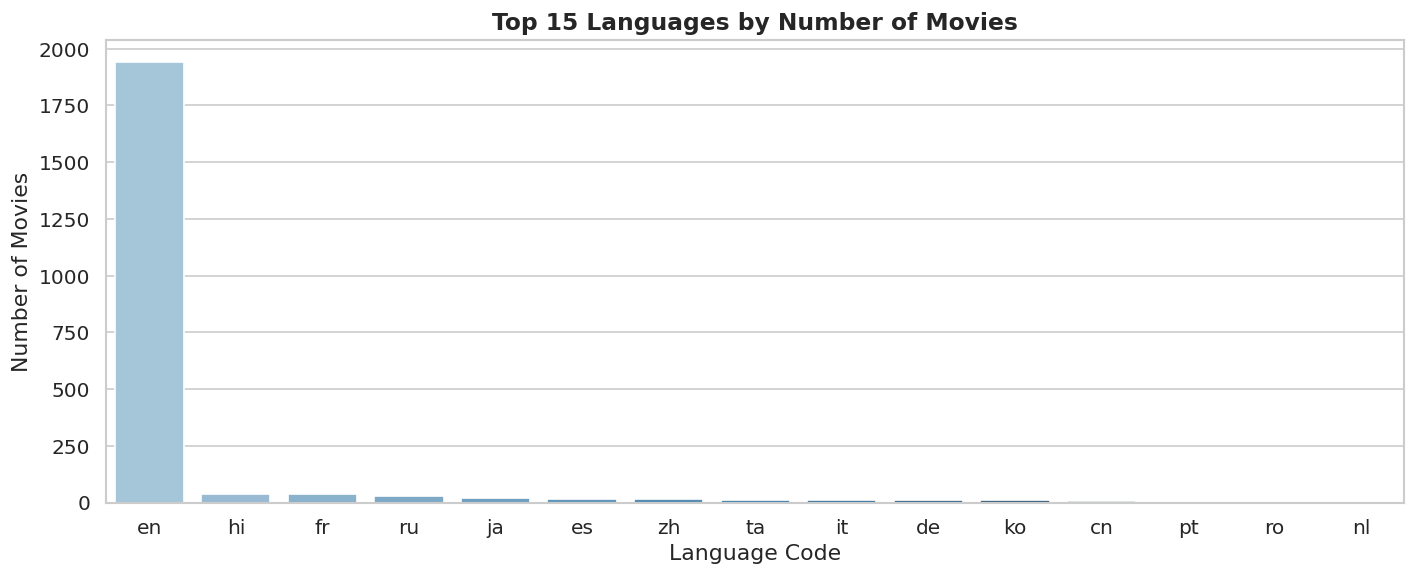

In [29]:
print("\n" + "="*60)
print("   Q2 : LANGUAGE WITH HIGHEST AVERAGE ROI")
print("="*60)

# Keep languages with at least 5 movies for statistical reliability
lang_stats = (
    df_clean.groupby("original_language")
    .agg(avg_roi=("roi", "mean"), movie_count=("title", "count"))
    .reset_index()
)
lang_stats_filtered = lang_stats[lang_stats["movie_count"] >= 5].sort_values("avg_roi", ascending=False)

print(f"\n🌍  Top 10 Languages by Average ROI (min 5 movies):")
display(lang_stats_filtered.head(10).rename(columns={
    "original_language": "Language",
    "avg_roi": "Avg ROI (%)",
    "movie_count": "# Movies"
}).reset_index(drop=True))

top_lang = lang_stats_filtered.iloc[0]
print(f"\n🥇  Highest Avg ROI Language : '{top_lang['original_language'].upper()}'"
      f"  →  {top_lang['avg_roi']:.1f}% (based on {int(top_lang['movie_count'])} movies)")

# Bar chart – Top 10 languages
plt.figure(figsize=(12, 6))
top10_lang = lang_stats_filtered.head(10)
bars = plt.bar(top10_lang["original_language"], top10_lang["avg_roi"],
               color=sns.color_palette("viridis", 10), edgecolor="white")
plt.title("Top 10 Languages by Average ROI (min 5 movies)", fontsize=14, fontweight="bold")
plt.xlabel("Language Code")
plt.ylabel("Average ROI (%)")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# Number of movies per language (top 15)
top15_by_count = lang_stats.sort_values("movie_count", ascending=False).head(15)
plt.figure(figsize=(12, 5))
sns.barplot(data=top15_by_count, x="original_language", y="movie_count",
            palette="Blues_d", edgecolor="white")
plt.title("Top 15 Languages by Number of Movies", fontsize=14, fontweight="bold")
plt.xlabel("Language Code")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

# **3- Find out the unique genres of movies in this dataset.**


   Q3 : UNIQUE GENRES

🎭  Total unique genres found : 20

   ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']

📊  Genre frequency table:


,Genre,Count
0,Drama,1092
1,Comedy,730
2,Thriller,637
3,Action,612
4,Romance,410
5,Crime,376
6,Adventure,374
7,Science Fiction,248
8,Horror,243
9,Family,200


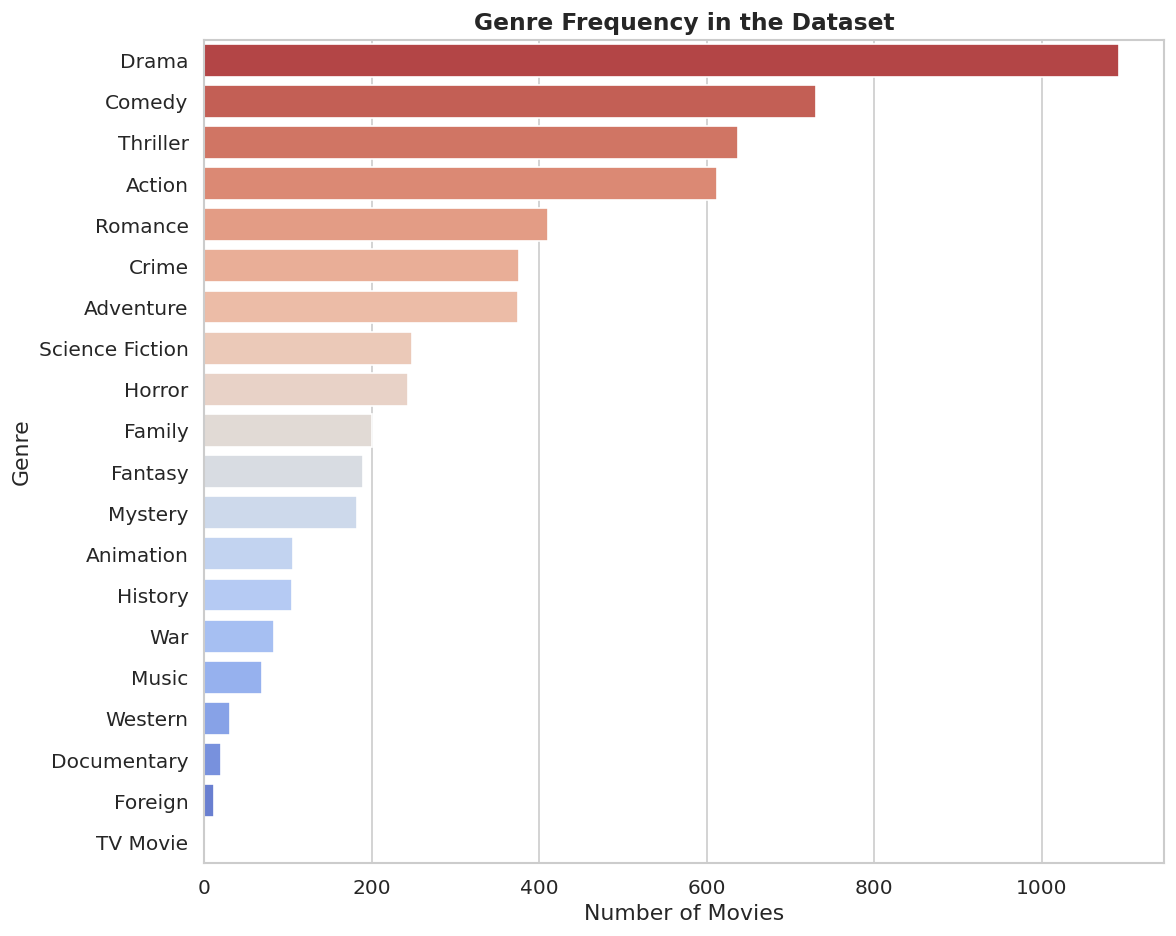

In [30]:
print("\n" + "="*60)
print("   Q3 : UNIQUE GENRES")
print("="*60)

# Explode genres
all_genres = df_clean["genre_list"].explode()
all_genres = all_genres[all_genres != ""].dropna()
unique_genres = sorted(all_genres.unique())

print(f"\n🎭  Total unique genres found : {len(unique_genres)}")
print(f"\n   {unique_genres}")

# Genre frequency
genre_counts = all_genres.value_counts().reset_index()
genre_counts.columns = ["Genre", "Count"]

print(f"\n📊  Genre frequency table:")
display(genre_counts)

# Horizontal bar chart
plt.figure(figsize=(10, 8))
sns.barplot(data=genre_counts, y="Genre", x="Count",
            palette="coolwarm_r", edgecolor="white")
plt.title("Genre Frequency in the Dataset", fontsize=14, fontweight="bold")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

# **4- Make a table of all the producers and directors of each movie. Find the top 3 producers who have produced movies with the highest average RoI?**


   Q4 : PRODUCER–DIRECTOR TABLE & TOP 3 PRODUCERS BY ROI

📋  Producer–Director table  (5051 rows):


,Movie,Producer,Director,Profit ($M),ROI (%)
0,Hot Tub Time Machine 2,Andrew Panay,Steve Pink,-1.69,-12.0
1,The Princess Diaries 2: Royal Engagement,Whitney Houston,Garry Marshall,55.15,137.9
2,The Princess Diaries 2: Royal Engagement,Mario Iscovich,Garry Marshall,55.15,137.9
3,The Princess Diaries 2: Royal Engagement,Debra Martin Chase,Garry Marshall,55.15,137.9
4,Whiplash,David Lancaster,Damien Chazelle,9.79,296.7
5,Whiplash,Michel Litvak,Damien Chazelle,9.79,296.7
6,Whiplash,Jason Blum,Damien Chazelle,9.79,296.7
7,Whiplash,Helen Estabrook,Damien Chazelle,9.79,296.7
8,Kahaani,Sujoy Ghosh,Sujoy Ghosh,14.80,1233.3
9,A Mighty Wind,Karen Murphy,Christopher Guest,12.75,212.5



🏆  Top 3 Producers by Average ROI (min 3 movies):


,Producer,Avg_ROI,Movie_Count
0,Charlie Chaplin,2.833338e+08,3
1,Jerry Weintraub,2.037257e+07,5
2,Oren Peli,3.243341e+05,4


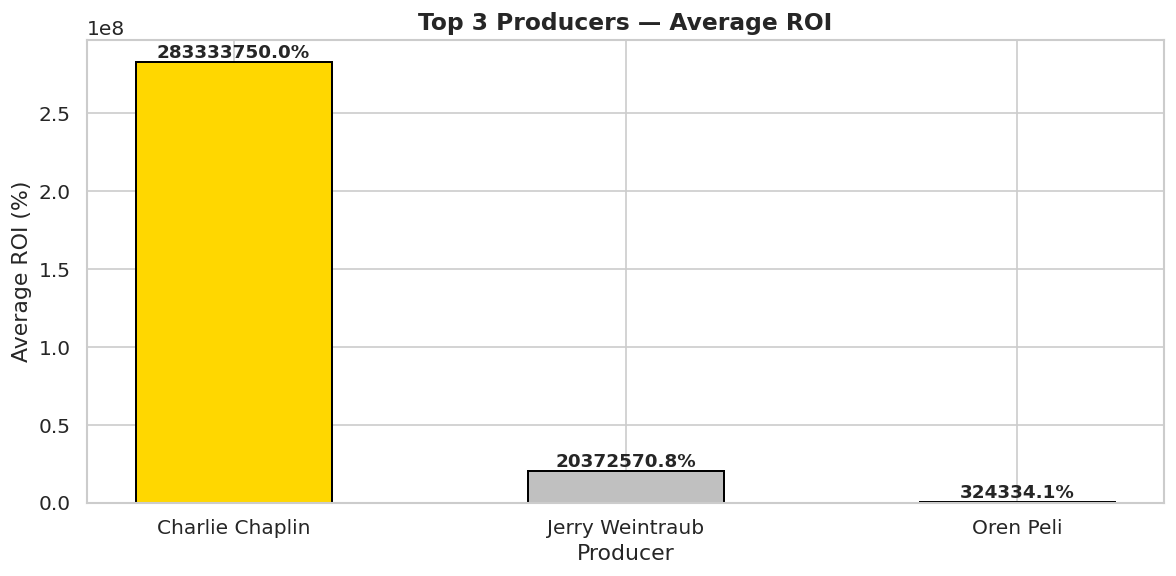

In [31]:
print("\n" + "="*60)
print("   Q4 : PRODUCER–DIRECTOR TABLE & TOP 3 PRODUCERS BY ROI")
print("="*60)

# ── Full producer-director table ─────────────────────────────
prod_dir_rows = []
for _, row in df_clean.iterrows():
    for prod in row["producer_list"]:
        for director in row["director_list"]:
            prod_dir_rows.append({
                "Movie": row["title"],
                "Producer": prod,
                "Director": director,
                "Profit ($M)": round(row["profit"] / 1e6, 2),
                "ROI (%)": round(row["roi"], 1)
            })

prod_dir_df = pd.DataFrame(prod_dir_rows)
print(f"\n📋  Producer–Director table  ({len(prod_dir_df)} rows):")
display(prod_dir_df.head(20))

# ── Top 3 Producers by Average ROI ──────────────────────────
# Explode so each producer gets its own row
prod_rows = []
for _, row in df_clean.iterrows():
    for prod in row["producer_list"]:
        prod_rows.append({"Producer": prod, "roi": row["roi"], "title": row["title"]})

prod_df = pd.DataFrame(prod_rows)

# Filter producers with at least 3 movies
prod_stats = (
    prod_df.groupby("Producer")
    .agg(Avg_ROI=("roi", "mean"), Movie_Count=("title", "count"))
    .reset_index()
    .query("Movie_Count >= 3")
    .sort_values("Avg_ROI", ascending=False)
    .reset_index(drop=True)
)

print(f"\n🏆  Top 3 Producers by Average ROI (min 3 movies):")
display(prod_stats.head(3))

top3_producers = prod_stats.head(3)

# Bar chart
plt.figure(figsize=(10, 5))
colors = ["gold", "silver", "#cd7f32"]
bars = plt.bar(top3_producers["Producer"], top3_producers["Avg_ROI"],
               color=colors, edgecolor="black", linewidth=1.2, width=0.5)
plt.title("Top 3 Producers — Average ROI", fontsize=14, fontweight="bold")
plt.ylabel("Average ROI (%)")
plt.xlabel("Producer")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

# **5- Which actor has acted in the most number of movies? Deep dive into the movies, genres and profits corresponding to this actor.**


   Q5 : ACTOR WITH MOST MOVIES — DEEP DIVE

🎭  Most active actor : Samuel L. Jackson  (25 movies)

📋  Movies featuring Samuel L. Jackson:


,Movie,Profit,ROI,Revenue,Budget
18542,The Avengers,1299557910,590.708141,1519557910,220000000
45911,Avengers: Age of Ultron,1125403694,401.929891,1405403694,280000000
29135,Jurassic Park,857100000,1360.476190,920100000,63000000
11257,Star Wars: Episode III - Revenge of the Sith,737000000,652.212389,850000000,113000000
30694,Captain America: The Winter Soldier,544766572,320.450925,714766572,170000000
45466,The Incredibles,539442092,586.350100,631442092,92000000
30162,Star Wars: Episode II - Attack of the Clones,529398328,441.165273,649398328,120000000
10168,Coming to America,249752301,640.390515,288752301,39000000
19471,Jumper,137231186,161.448454,222231186,85000000
48057,Patriot Games,133051587,295.670193,178051587,45000000



🎬  Genre distribution for Samuel L. Jackson:


,Genre,Count
0,Action,16
1,Crime,12
2,Adventure,11
3,Thriller,10
4,Science Fiction,9
5,Drama,6
6,Mystery,5
7,Comedy,3
8,Romance,3
9,Western,1


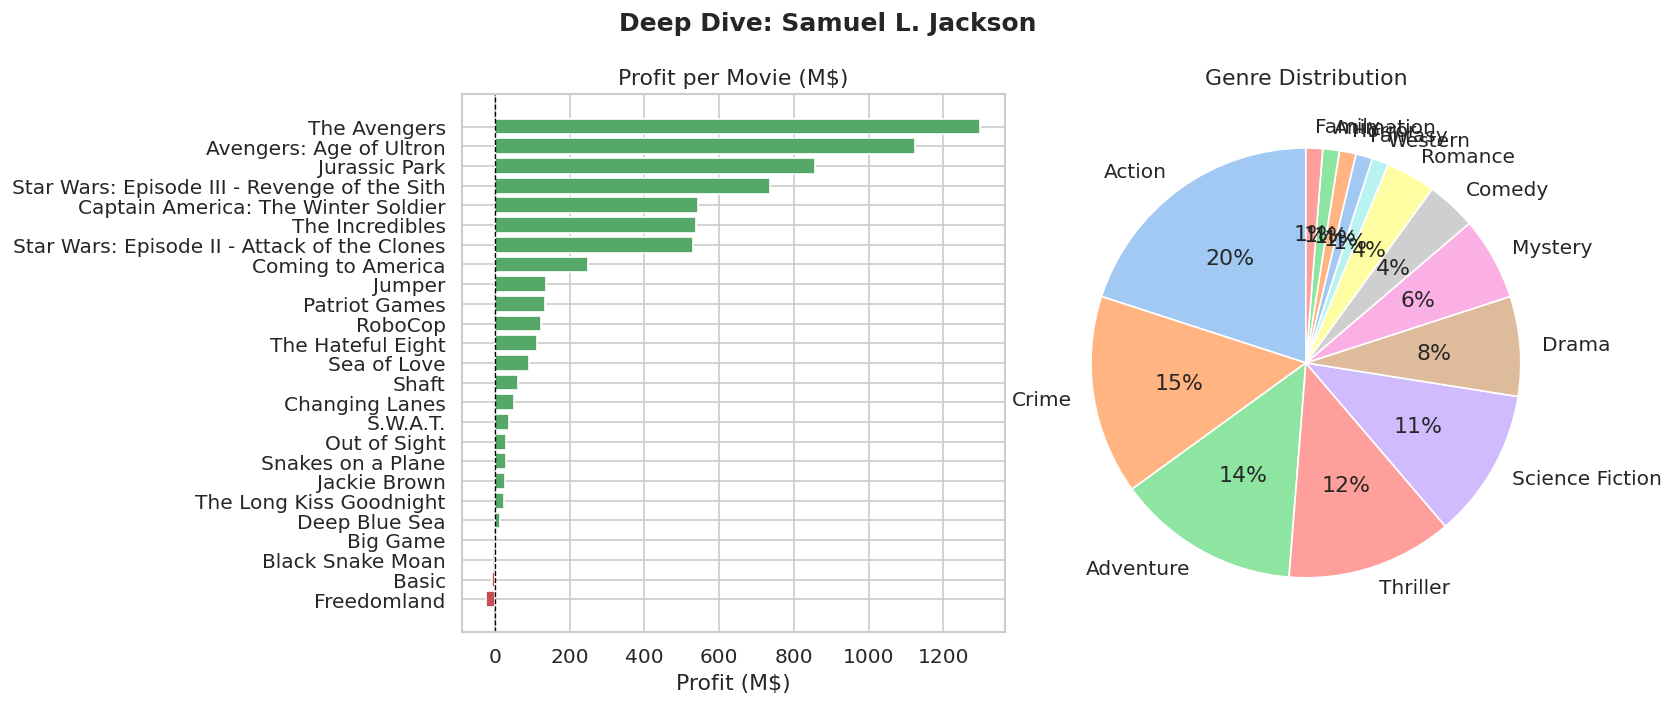

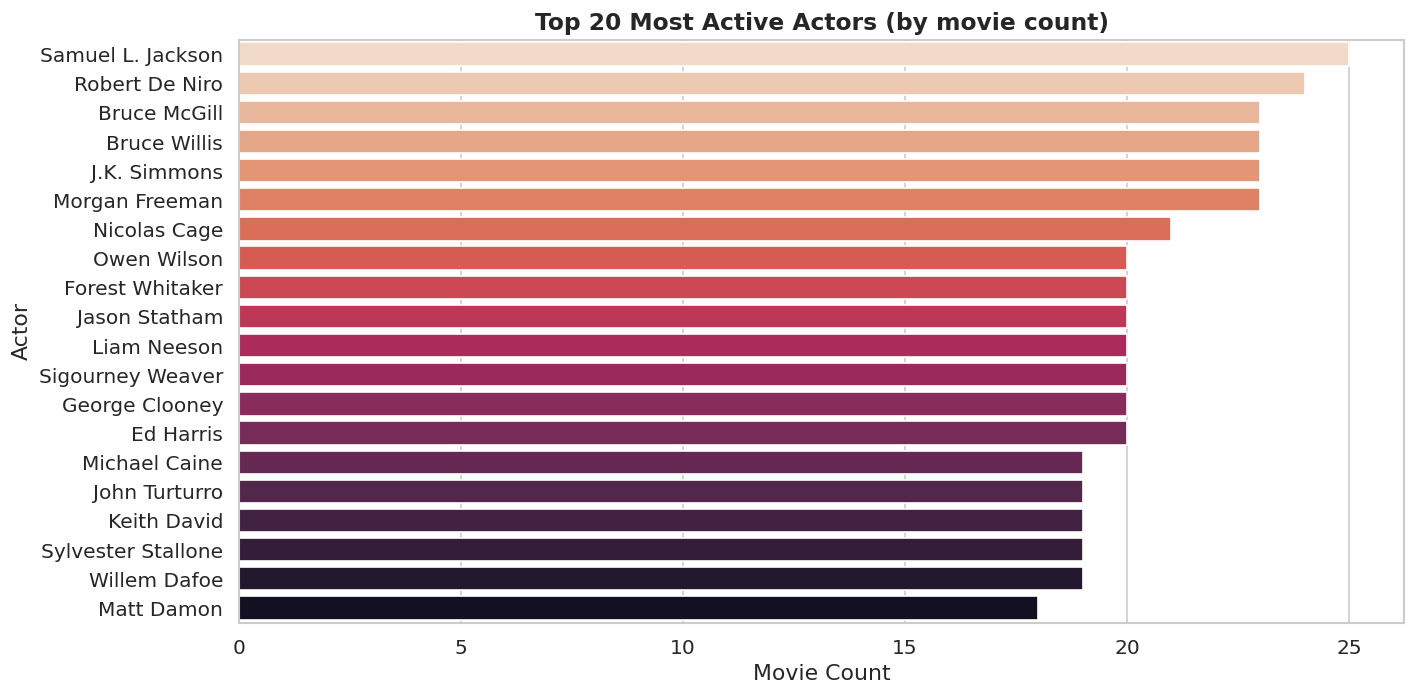

In [32]:
print("\n" + "="*60)
print("   Q5 : ACTOR WITH MOST MOVIES — DEEP DIVE")
print("="*60)

# Explode cast
cast_rows = []
for _, row in df_clean.iterrows():
    for actor in row["cast_list"]:
        cast_rows.append({
            "Actor":  actor,
            "Movie":  row["title"],
            "Genres": row["genre_list"],
            "Profit": row["profit"],
            "ROI":    row["roi"],
            "Revenue": row["revenue"],
            "Budget":  row["budget"]
        })

cast_df = pd.DataFrame(cast_rows)

# Most active actor
actor_counts = cast_df["Actor"].value_counts()
top_actor = actor_counts.index[0]
top_actor_count = actor_counts.iloc[0]
print(f"\n🎭  Most active actor : {top_actor}  ({top_actor_count} movies)")

# Filter for that actor
actor_movies = cast_df[cast_df["Actor"] == top_actor].copy()

print(f"\n📋  Movies featuring {top_actor}:")
display(actor_movies[["Movie", "Profit", "ROI", "Revenue", "Budget"]].sort_values("Profit", ascending=False))

# Genre breakdown for this actor
actor_genres = actor_movies["Genres"].explode().value_counts().reset_index()
actor_genres.columns = ["Genre", "Count"]
print(f"\n🎬  Genre distribution for {top_actor}:")
display(actor_genres)

# ── Visualisations ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Deep Dive: {top_actor}", fontsize=15, fontweight="bold")

# Profit by movie
sorted_movies = actor_movies.sort_values("Profit", ascending=True)
axes[0].barh(sorted_movies["Movie"], sorted_movies["Profit"] / 1e6,
             color=["#C44E52" if p < 0 else "#55A868" for p in sorted_movies["Profit"]],
             edgecolor="white")
axes[0].set_title("Profit per Movie (M$)")
axes[0].set_xlabel("Profit (M$)")
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")

# Genre pie chart
axes[1].pie(actor_genres["Count"], labels=actor_genres["Genre"], autopct="%1.0f%%",
            colors=sns.color_palette("pastel"), startangle=90)
axes[1].set_title("Genre Distribution")

plt.tight_layout()
plt.show()

# Top 20 most active actors bar chart
plt.figure(figsize=(12, 6))
top20_actors = actor_counts.head(20).reset_index()
top20_actors.columns = ["Actor", "Movie Count"]
sns.barplot(data=top20_actors, x="Movie Count", y="Actor", palette="rocket_r", edgecolor="white")
plt.title("Top 20 Most Active Actors (by movie count)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# **6- Top 3 directors prefer which actors the most?**


   Q6 : TOP 3 DIRECTORS — PREFERRED ACTORS

🎬  Top 3 Directors (by movie count): ['Steven Spielberg', 'Clint Eastwood', 'Michael Bay']

📽️  Steven Spielberg — Top 10 preferred actors:


,Actor,Count
0,Harrison Ford,3
1,Pat Roach,2
2,Tom Hanks,2
3,Richard Dreyfuss,2
4,Steven Spielberg,2
5,Ted Grossman,2
6,Joe Starr,2
7,Sasha Spielberg,2
8,Deirdre Laird,1
9,Samantha Hughes,1



📽️  Clint Eastwood — Top 10 preferred actors:


,Actor,Count
0,Clint Eastwood,6
1,Annie O'Donnell,2
2,Laura Linney,2
3,Mara Corday,2
4,Sondra Locke,2
5,Pat Hingle,2
6,Clint Ward,2
7,Cayden Boyd,1
8,Miles Herter,1
9,T. Bruce Page,1



📽️  Michael Bay — Top 10 preferred actors:


,Actor,Count
0,Frank Welker,4
1,Mark Ryan,4
2,Reno Wilson,4
3,Peter Cullen,4
4,Jess Harnell,4
5,Josh Duhamel,4
6,Glenn Morshower,4
7,John Turturro,4
8,Robert Foxworth,3
9,Shia LaBeouf,3


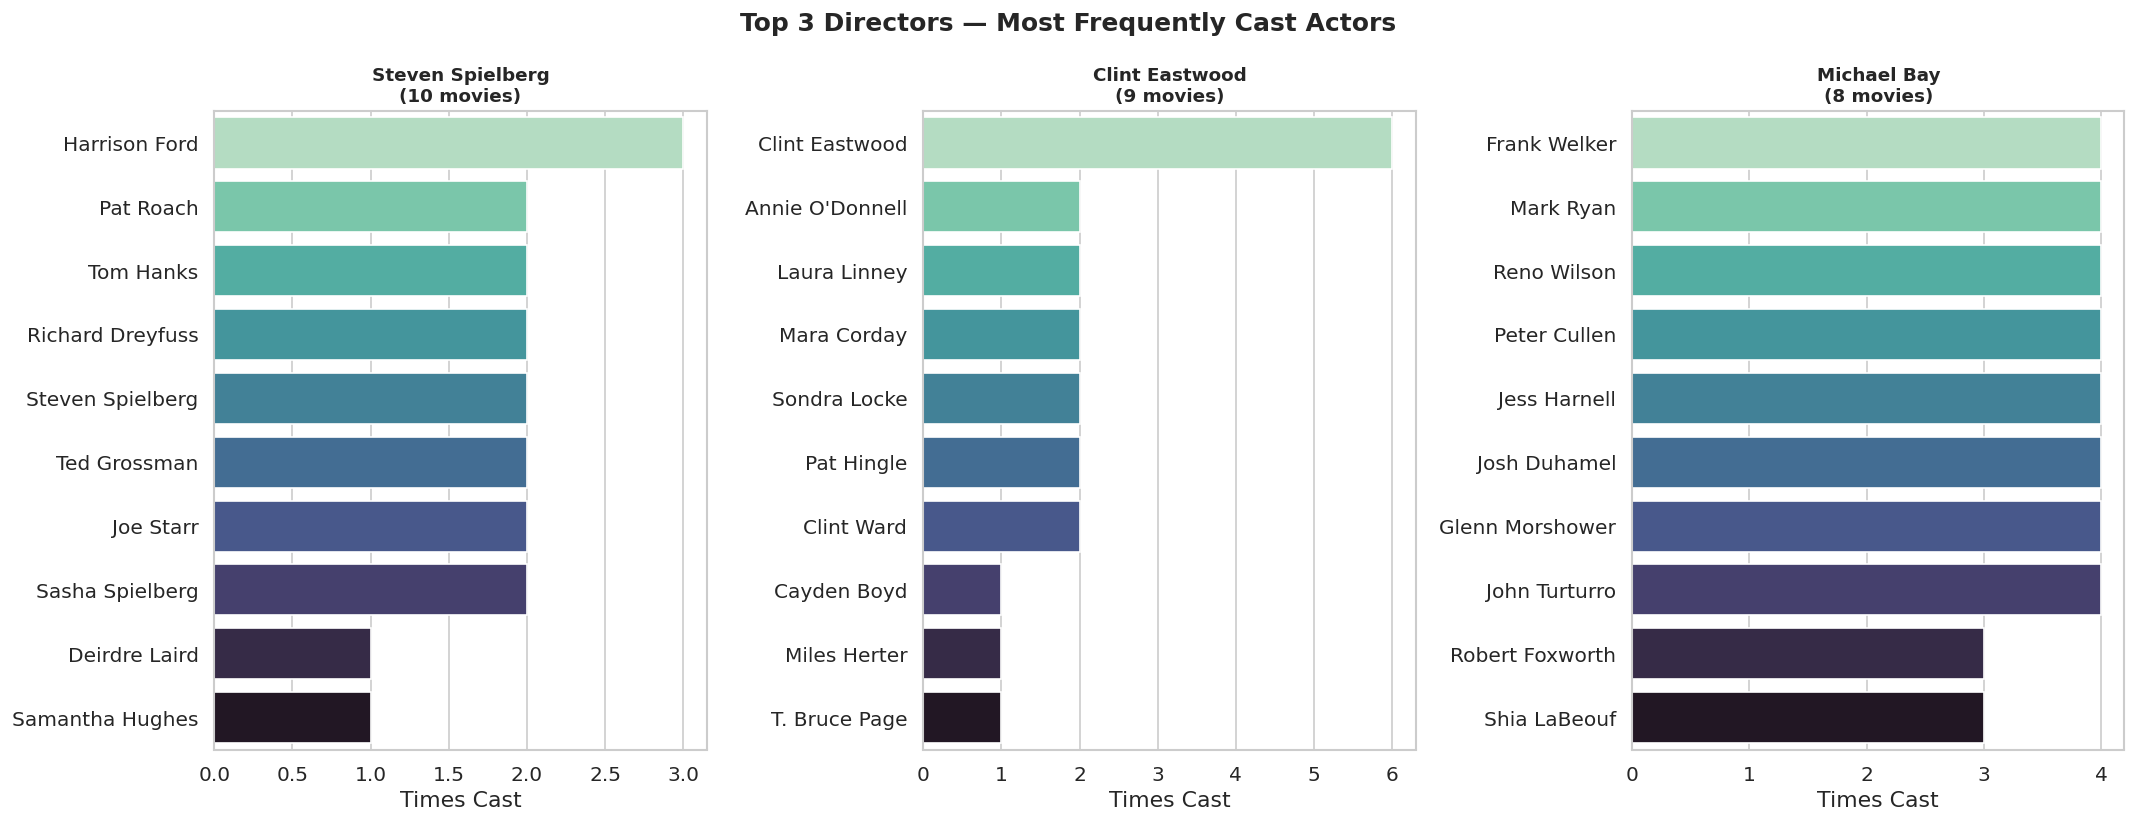

In [33]:
print("\n" + "="*60)
print("   Q6 : TOP 3 DIRECTORS — PREFERRED ACTORS")
print("="*60)

# Explode directors
dir_rows = []
for _, row in df_clean.iterrows():
    for director in row["director_list"]:
        dir_rows.append({
            "Director": director,
            "Movie":    row["title"],
            "Cast":     row["cast_list"],
            "Profit":   row["profit"],
            "ROI":      row["roi"]
        })

dir_df = pd.DataFrame(dir_rows)

# Top 3 directors by movie count
top3_directors = dir_df["Director"].value_counts().head(3).index.tolist()
print(f"\n🎬  Top 3 Directors (by movie count): {top3_directors}")

# For each director, find their most-cast actors
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Top 3 Directors — Most Frequently Cast Actors", fontsize=15, fontweight="bold")

for ax, director in zip(axes, top3_directors):
    dir_movies = dir_df[dir_df["Director"] == director]
    actor_freq = dir_movies["Cast"].explode().value_counts().head(10).reset_index()
    actor_freq.columns = ["Actor", "Count"]

    print(f"\n📽️  {director} — Top 10 preferred actors:")
    display(actor_freq)

    sns.barplot(data=actor_freq, x="Count", y="Actor", ax=ax,
                palette="mako_r", edgecolor="white")
    ax.set_title(f"{director}\n({len(dir_movies)} movies)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Times Cast")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

# **BONUS — GENRE PROFITABILITY**


   BONUS : GENRE PROFITABILITY ANALYSIS

📊  Genre Profitability Summary:


,Genre,Avg_Profit,Avg_ROI,Count
0,Adventure,1.376887e+08,2.732341e+05,374
1,Animation,1.327592e+08,2.325127e+02,106
2,Fantasy,1.181118e+08,2.300762e+02,189
3,Family,1.169029e+08,5.095336e+05,200
4,Science Fiction,8.985734e+07,2.648028e+02,248
5,Action,8.224624e+07,1.670199e+05,612
6,Comedy,5.153056e+07,1.743437e+06,730
7,Thriller,4.955530e+07,1.576205e+05,637
8,Romance,4.668373e+07,2.553460e+05,410
9,Horror,4.522495e+07,4.194850e+05,243


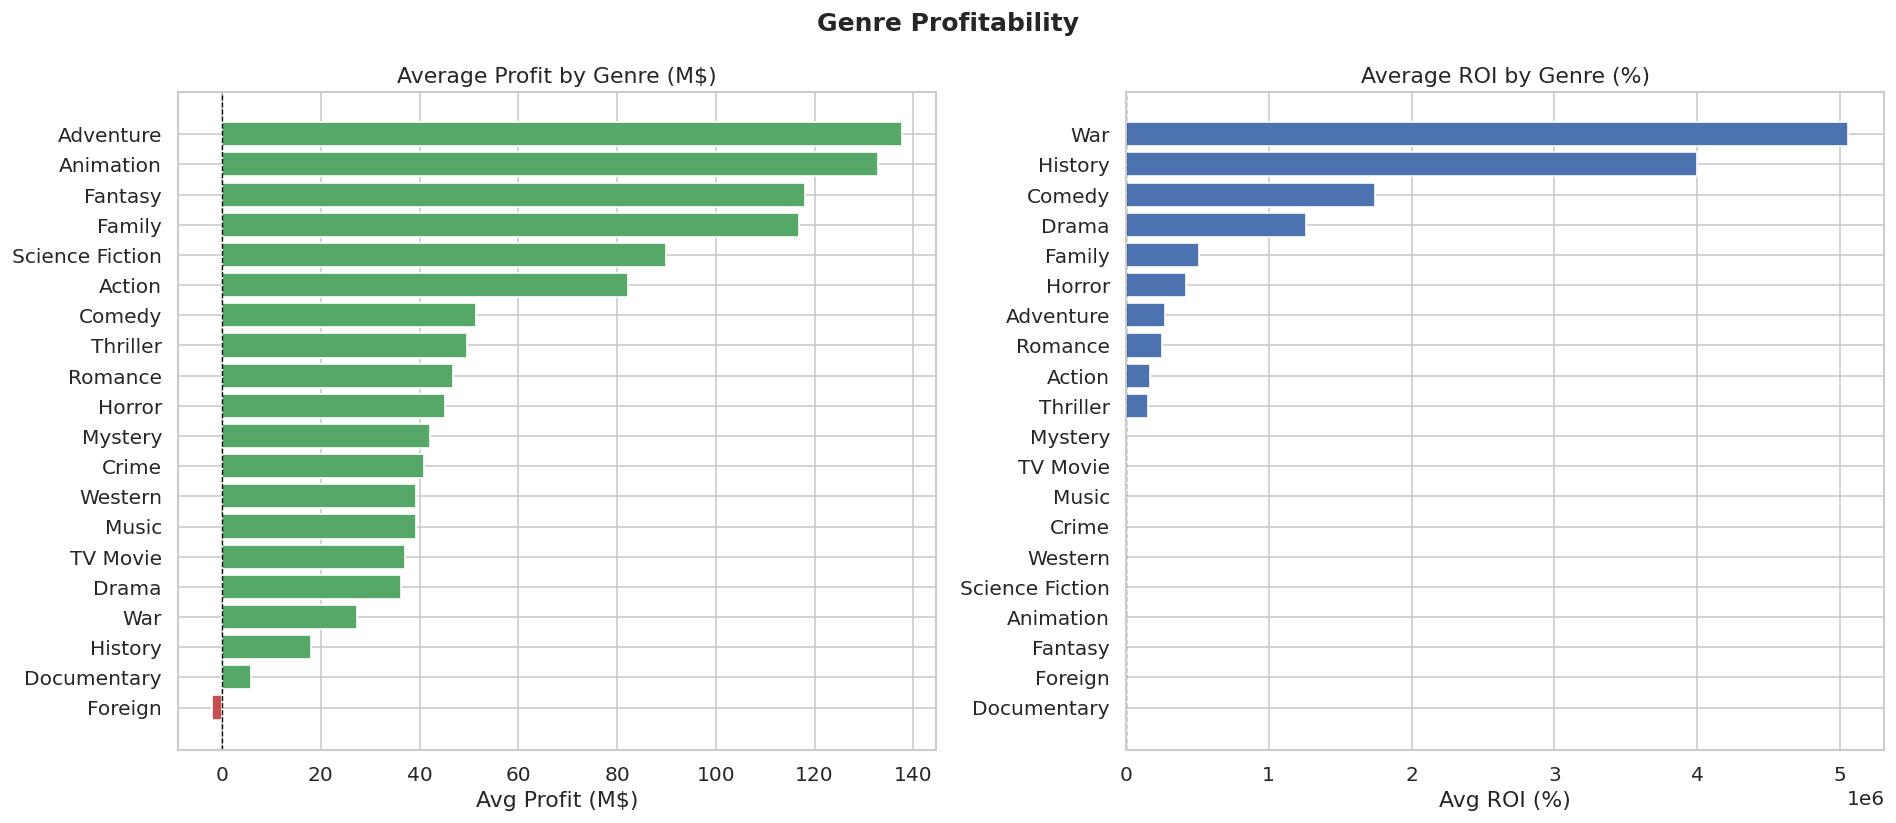


  ✅  ALL ANALYSES COMPLETE — GOOD LUCK WITH YOUR PROJECT!


In [34]:
print("\n" + "="*60)
print("   BONUS : GENRE PROFITABILITY ANALYSIS")
print("="*60)

genre_rows = []
for _, row in df_clean.iterrows():
    for genre in row["genre_list"]:
        genre_rows.append({"Genre": genre, "Profit": row["profit"], "ROI": row["roi"]})

genre_profit_df = pd.DataFrame(genre_rows)
genre_summary = (
    genre_profit_df.groupby("Genre")
    .agg(Avg_Profit=("Profit", "mean"), Avg_ROI=("ROI", "mean"), Count=("Profit", "count"))
    .sort_values("Avg_Profit", ascending=False)
    .reset_index()
)

print("\n📊  Genre Profitability Summary:")
display(genre_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Genre Profitability", fontsize=15, fontweight="bold")

genre_summary_sorted_profit = genre_summary.sort_values("Avg_Profit", ascending=True)
axes[0].barh(genre_summary_sorted_profit["Genre"],
             genre_summary_sorted_profit["Avg_Profit"] / 1e6,
             color=["#C44E52" if p < 0 else "#55A868"
                    for p in genre_summary_sorted_profit["Avg_Profit"]],
             edgecolor="white")
axes[0].set_title("Average Profit by Genre (M$)")
axes[0].set_xlabel("Avg Profit (M$)")
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")

genre_summary_sorted_roi = genre_summary.sort_values("Avg_ROI", ascending=True)
axes[1].barh(genre_summary_sorted_roi["Genre"],
             genre_summary_sorted_roi["Avg_ROI"],
             color=["#C44E52" if r < 0 else "#4C72B0"
                    for r in genre_summary_sorted_roi["Avg_ROI"]],
             edgecolor="white")
axes[1].set_title("Average ROI by Genre (%)")
axes[1].set_xlabel("Avg ROI (%)")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("  ✅  ALL ANALYSES COMPLETE — GOOD LUCK WITH YOUR PROJECT!")
print("="*60)